**- Essential Libraries**

In [50]:
#pip install pmdarima
#pip install tensorboard


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.special import boxcox, inv_boxcox
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error,mean_squared_error
from IPython.display import display
from scipy import stats
import pmdarima as pm
from keras.models import Sequential
from keras.layers import Dense , SimpleRNN
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping, ReduceLROnPlateau , ModelCheckpoint
import os
import warnings
import itertools
import datetime

warnings.filterwarnings("ignore")
%matplotlib inline

**- Setting Matplotlib and Seaborn Parameters for the whole notebook**

In [51]:

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="muted"
)

plt.rcParams.update({
    "figure.figsize": (16, 6),
    "axes.titlesize": 16,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.alpha": 0.25,
    "lines.linewidth": 1.8
})


**-Loading DataSet**

In [52]:
try:

    df = pd.read_csv('ADANIPORTS.csv', parse_dates=['Date'], index_col='Date')   
    df = df.sort_index()
    
    print('The dataset was loaded successfully...')

except Exception as e:
    

  print('Download failed', e)


The dataset was loaded successfully...


In [53]:
df

,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
Date,,,,,,,,,,,,,,
2007-11-27,MUNDRAPORT,EQ,440.00,770.00,1050.00,770.00,959.0,962.90,984.72,27294366,2.687719e+15,NaN,9859619,0.3612
2007-11-28,MUNDRAPORT,EQ,962.90,984.00,990.00,874.00,885.0,893.90,941.38,4581338,4.312765e+14,NaN,1453278,0.3172
2007-11-29,MUNDRAPORT,EQ,893.90,909.00,914.75,841.00,887.0,884.20,888.09,5124121,4.550658e+14,NaN,1069678,0.2088
2007-11-30,MUNDRAPORT,EQ,884.20,890.00,958.00,890.00,929.0,921.55,929.17,4609762,4.283257e+14,NaN,1260913,0.2735
2007-12-03,MUNDRAPORT,EQ,921.55,939.75,995.00,922.00,980.0,969.30,965.65,2977470,2.875200e+14,NaN,816123,0.2741
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-26,ADANIPORTS,EQ,725.35,733.00,739.65,728.90,729.2,730.75,733.25,9390549,6.885658e+14,116457.0,838079,0.0892
2021-04-27,ADANIPORTS,EQ,730.75,735.00,757.50,727.35,748.6,749.15,747.67,20573107,1.538191e+15,236896.0,1779639,0.0865
2021-04-28,ADANIPORTS,EQ,749.15,755.00,760.00,741.10,743.4,746.25,751.02,11156977,8.379106e+14,130847.0,1342353,0.1203


# **1- Data Understanding**

In [54]:
#General DataFrame information
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3322 entries, 2007-11-27 to 2021-04-30
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Symbol              3322 non-null   object 
 1   Series              3322 non-null   object 
 2   Prev Close          3322 non-null   float64
 3   Open                3322 non-null   float64
 4   High                3322 non-null   float64
 5   Low                 3322 non-null   float64
 6   Last                3322 non-null   float64
 7   Close               3322 non-null   float64
 8   VWAP                3322 non-null   float64
 9   Volume              3322 non-null   int64  
 10  Turnover            3322 non-null   float64
 11  Trades              2456 non-null   float64
 12  Deliverable Volume  3322 non-null   int64  
 13  %Deliverble         3322 non-null   float64
dtypes: float64(10), int64(2), object(2)
memory usage: 389.3+ KB


## DataExplorer Class Definition

*This class is designed to help understand and explore time series data. It provides methods for visualizing the series, examining its distribution, detecting outliers, analyzing rolling statistics, performing decomposition, checking missing values, and evaluating autocorrelation structure.*

### Available Methods

- `set_caption()`  
  Sets a descriptive label for the dataset.

- `plot_time_series()`  
  Plots the time series data.

- `plot_box_hist()`  
  Displays both a boxplot and a histogram of the data.

- `outlier_report()`  
  Detects outliers using the IQR method and presents a summary report.

- `plot_rolling_mean_std()`  
  Plots the rolling mean and rolling standard deviation of the series.

- `plot_decomposition()`  
  Decomposes the time series into trend, seasonal, and residual components.

- `check_missing_values()`  
  Checks and prints the number of missing values in the dataset.

- `ACF_and_PACF()`  
  Plots the ACF and PACF charts of the time series.


In [55]:
class DataExplorer:

    def __init__(self, data):

        #Save the original data and define a caption to use in the chart title.
        
        self.data = data
        self.caption  = None
# *************************************************************************************
    
    def set_caption(self, caption):

        # Specify data title/label to display in reports and charts
        
        self.caption = caption
        return self

# *************************************************************************************

    def plot_time_series(self , ax=None):

        # If no axis is given, a new shape is created

        if ax is None:
            fig, ax = plt.subplots(figsize=(14, 5))
            show = True
        else:
            show = False

        # Plotting time series data

        ax.plot(self.data , label='VWAP ', alpha=0.5)
        ax.set_title(f'Time Series Plot: {self.caption}')
        ax.set_xlabel('Date')
        ax.set_ylabel(f'{self.caption}')
        ax.legend()
        ax.grid(True , alpha=0.3)

        # Only display the plot when it is created inside this method

        if show:
            plt.tight_layout()
            plt.show()

        return self

# *************************************************************************************
    
    def plot_box_hist(self):

        # Create two charts to examine the data distribution:
        # One is a boxplot and the other is a histogram
        
        fig, axes = plt.subplots(2, 1, figsize=(14, 5))

        axes[0].boxplot(self.data, vert=False)
        axes[0].set_title(f'Boxplot of {self.caption}')
        axes[0].set_xlabel(f'{self.caption}')
        axes[0].grid(True, alpha=0.3)

        sns.histplot(self.data,
                    bins=30,
                    kde=True,
                    ax=axes[1],
                    alpha=0.7
                    )
        axes[1].set_title(f'Histogram of {self.caption}')
        axes[1].set_xlabel(f'{self.caption}')
        axes[1].set_ylabel('Frequency')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        return self

# *************************************************************************************   
    
    def outlier_report(self , threshold = 1.5):

        # Calculating the first and third quartiles

        Q1 = self.data.quantile(0.25)
        Q3 = self.data.quantile(0.75)

        # Calculate the interquartile range
    
        IQR = Q3 - Q1

        # Determining the allowable interval based on the IQR method
    
        lower_bound = Q1 - threshold * IQR
        upper_bound = Q3 + threshold * IQR

        # Extracting outliers
    
        outliers = self.data[
                            (self.data < lower_bound) |
                            (self.data > upper_bound)
                            ]
    
        outlier_count = len(outliers)
    
        total_count = len(self.data)
    
        outlier_percentage = (outlier_count / total_count) * 100

        # Create an outlier report table
    
        report = pd.DataFrame({
                                'Metric': [
                                            'Threshold',
                                            'Q1',
                                            'Q3',
                                            'IQR',
                                            'Lower Bound',
                                            'Upper Bound',
                                            'Total Samples',
                                            'Outlier Count',
                                            'Outlier Percentage (%)'
                                            ],
                                 'Value': [
                                            threshold,
                                            Q1,
                                            Q3,
                                            IQR,
                                            lower_bound,
                                            upper_bound,
                                            total_count,
                                            outlier_count,
                                            round(outlier_percentage, 2)
                                            ]
                            })

        # Display the report in a styled way
        
        styled_report = report.style.set_caption(f'Outliers Report - {self.caption}')
        display(styled_report)

        # Save outlier data for later use

        self.outliers = outliers

        return self

# *************************************************************************************
    
    def plot_rolling_mean_std(self , window=30):

        # Calculate the moving average and standard deviation
        
        rolmean = self.data.rolling(window=window).mean()
        rolstd = self.data.rolling(window=window).std()

        # Plot the original data with rolling mean and rolling std

        orig = plt.plot(self.data,  label=f'{self.caption}')
        mean = plt.plot(rolmean,  label='Rolling Mean')
        std = plt.plot(rolstd,  label='Rolling Std')
        plt.xlabel('Date')
        plt.ylabel(f'{self.caption}')
        plt.legend()
        plt.title(f'Rolling Mean & Standard Deviation - {self.caption}')
        plt.tight_layout()
        plt.show()
        
        return self

# *************************************************************************************
    
    def plot_decomposition(self , model='additive' , period=252):

        # Decomposition of time series into trend / seasonal / residual components
        
        decomposition = seasonal_decompose(self.data, model = model, period=period)

        fig = decomposition.plot()
        fig.set_size_inches(14, 10)
        plt.suptitle(f'Decomposition of {self.caption} ({model.capitalize()} model)', fontsize=16, y=1.02)
        plt.tight_layout()  
        plt.show()

        return self
        
# *************************************************************************************
    
    def check_missing_values(self):
        
        # Count the number of missing values
        
        missing_count = self.data.isna().sum()

        print(f"Missing values in {self.caption} data: {missing_count}")

        return self

# *************************************************************************************
    
    def ACF_and_PACF(self):

        # Draw ACF and PACF charts to examine time dependence

        fig, axes = plt.subplots(2, 1, figsize=(17, 10))
        
        plot_acf(self.data, lags=30, ax=axes[0])
        axes[0].set_title(f'Autocorrelation Function (ACF) - {self.caption}') 
        
        plot_pacf(self.data, lags=30, ax=axes[1])
        axes[1].set_title(f'Partial Autocorrelation Function (PACF) - {self.caption}')
        
        plt.tight_layout()
        
        plt.show()
        
        return self


In [56]:
#Determine the target column

Data = df['VWAP'].copy()
Data

Date
2007-11-27    984.72
2007-11-28    941.38
2007-11-29    888.09
2007-11-30    929.17
2007-12-03    965.65
               ...  
2021-04-26    733.25
2021-04-27    747.67
2021-04-28    751.02
2021-04-29    753.06
2021-04-30    743.35
Name: VWAP, Length: 3322, dtype: float64

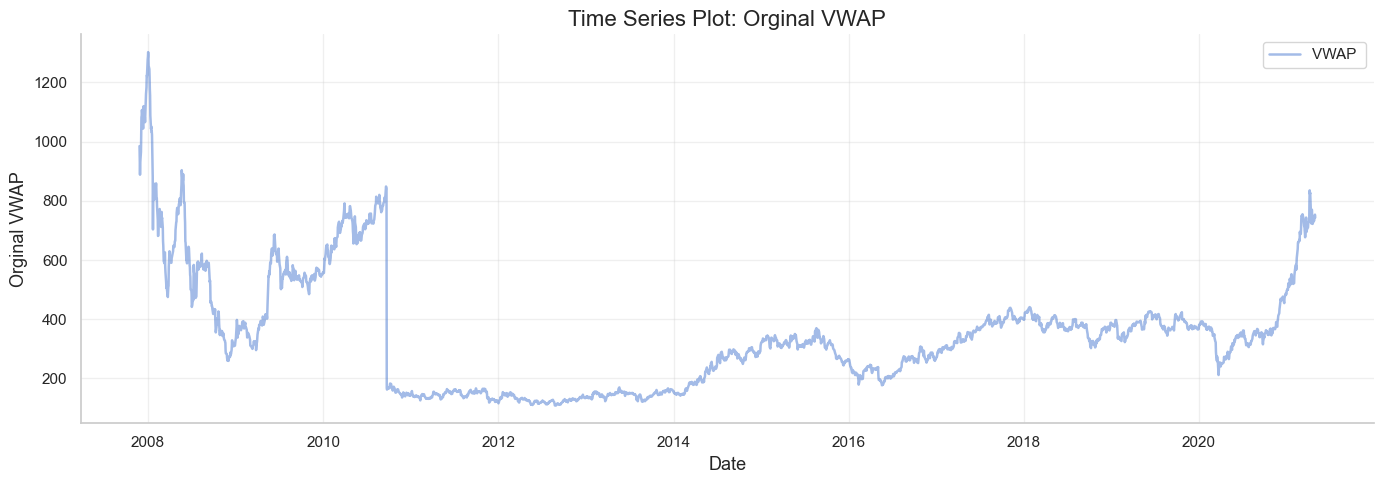

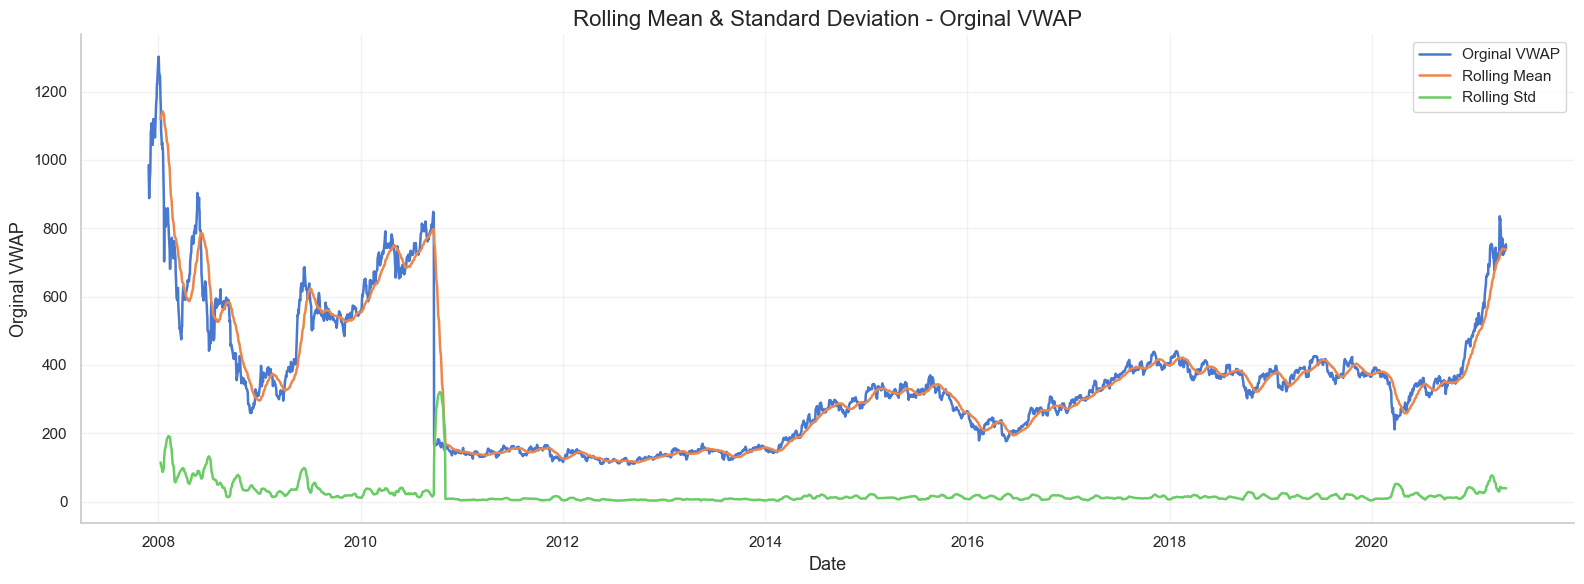

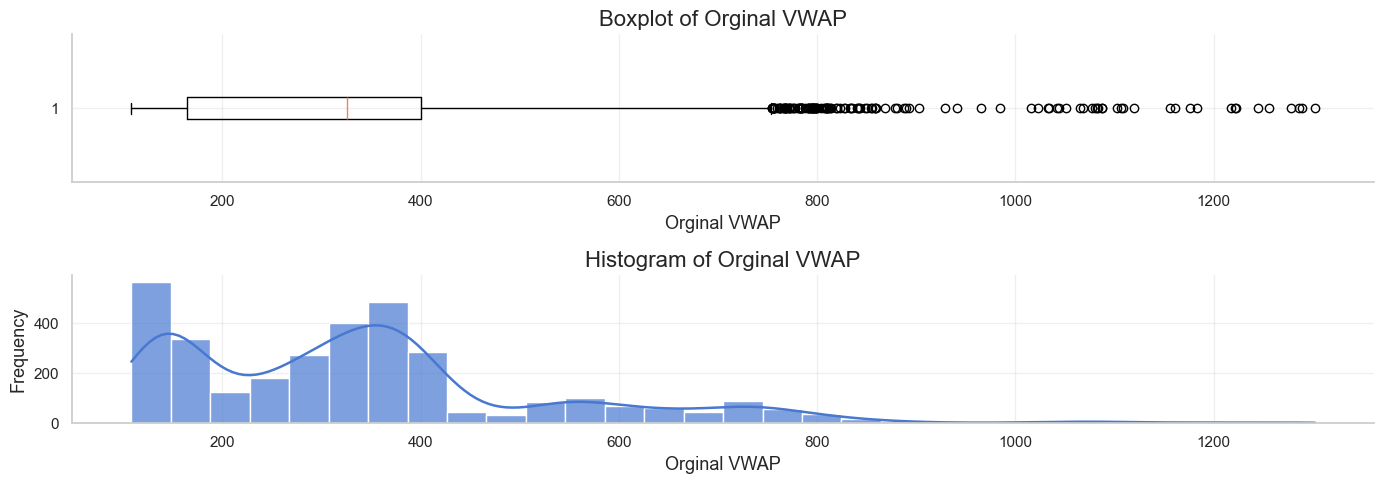

,Metric,Value
0,Threshold,1.500000
1,Q1,164.855000
2,Q3,400.607500
3,IQR,235.752500
4,Lower Bound,-188.773750
5,Upper Bound,754.236250
6,Total Samples,3322.000000
7,Outlier Count,131.000000
8,Outlier Percentage (%),3.940000


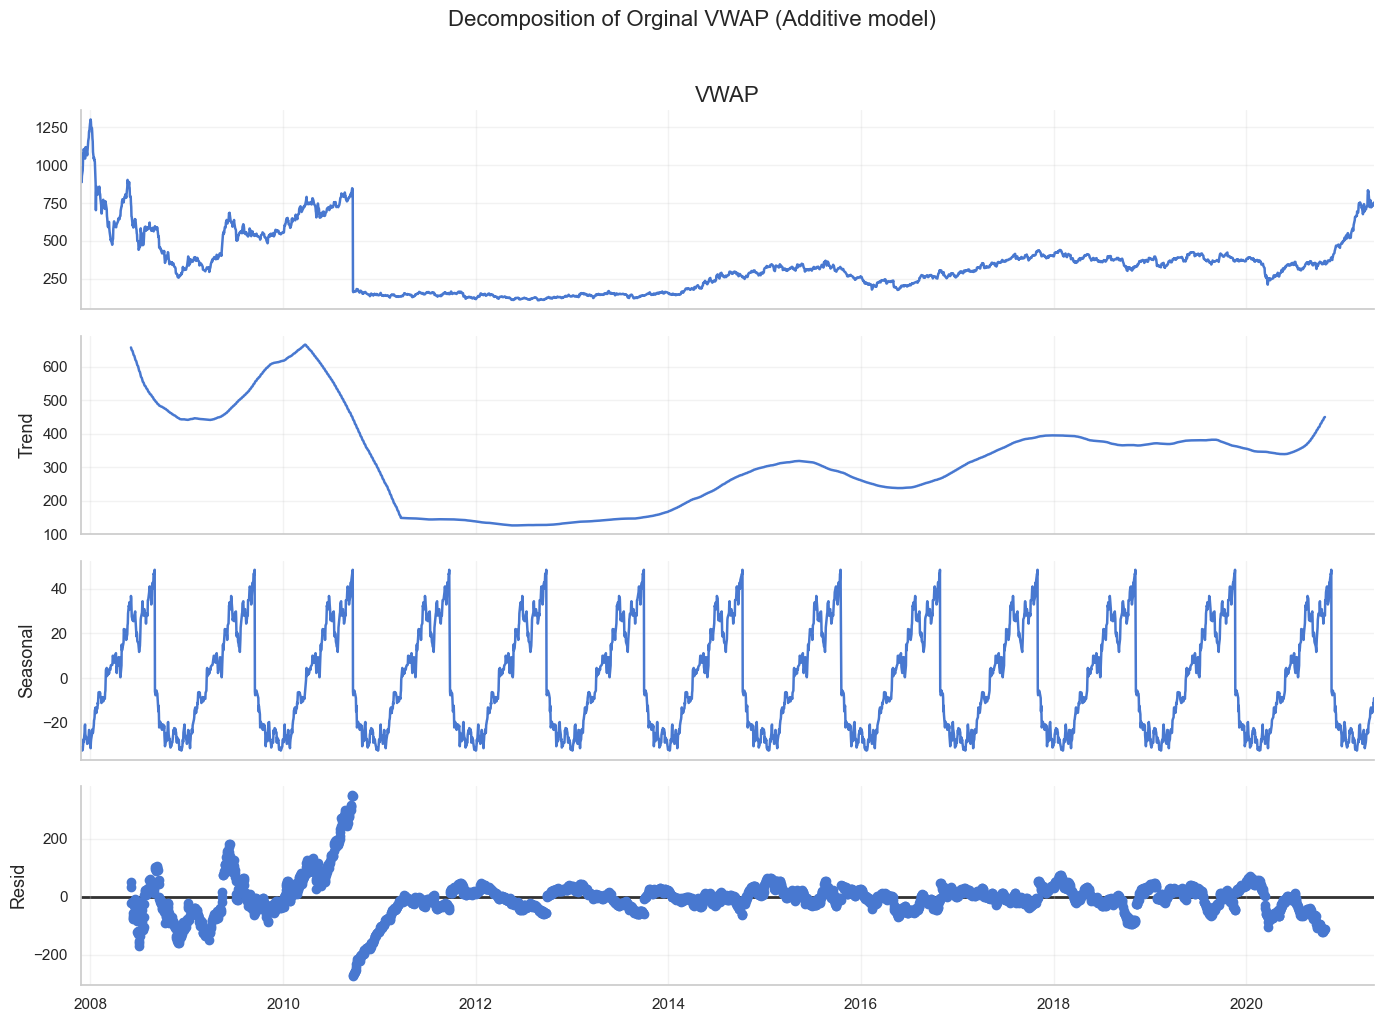

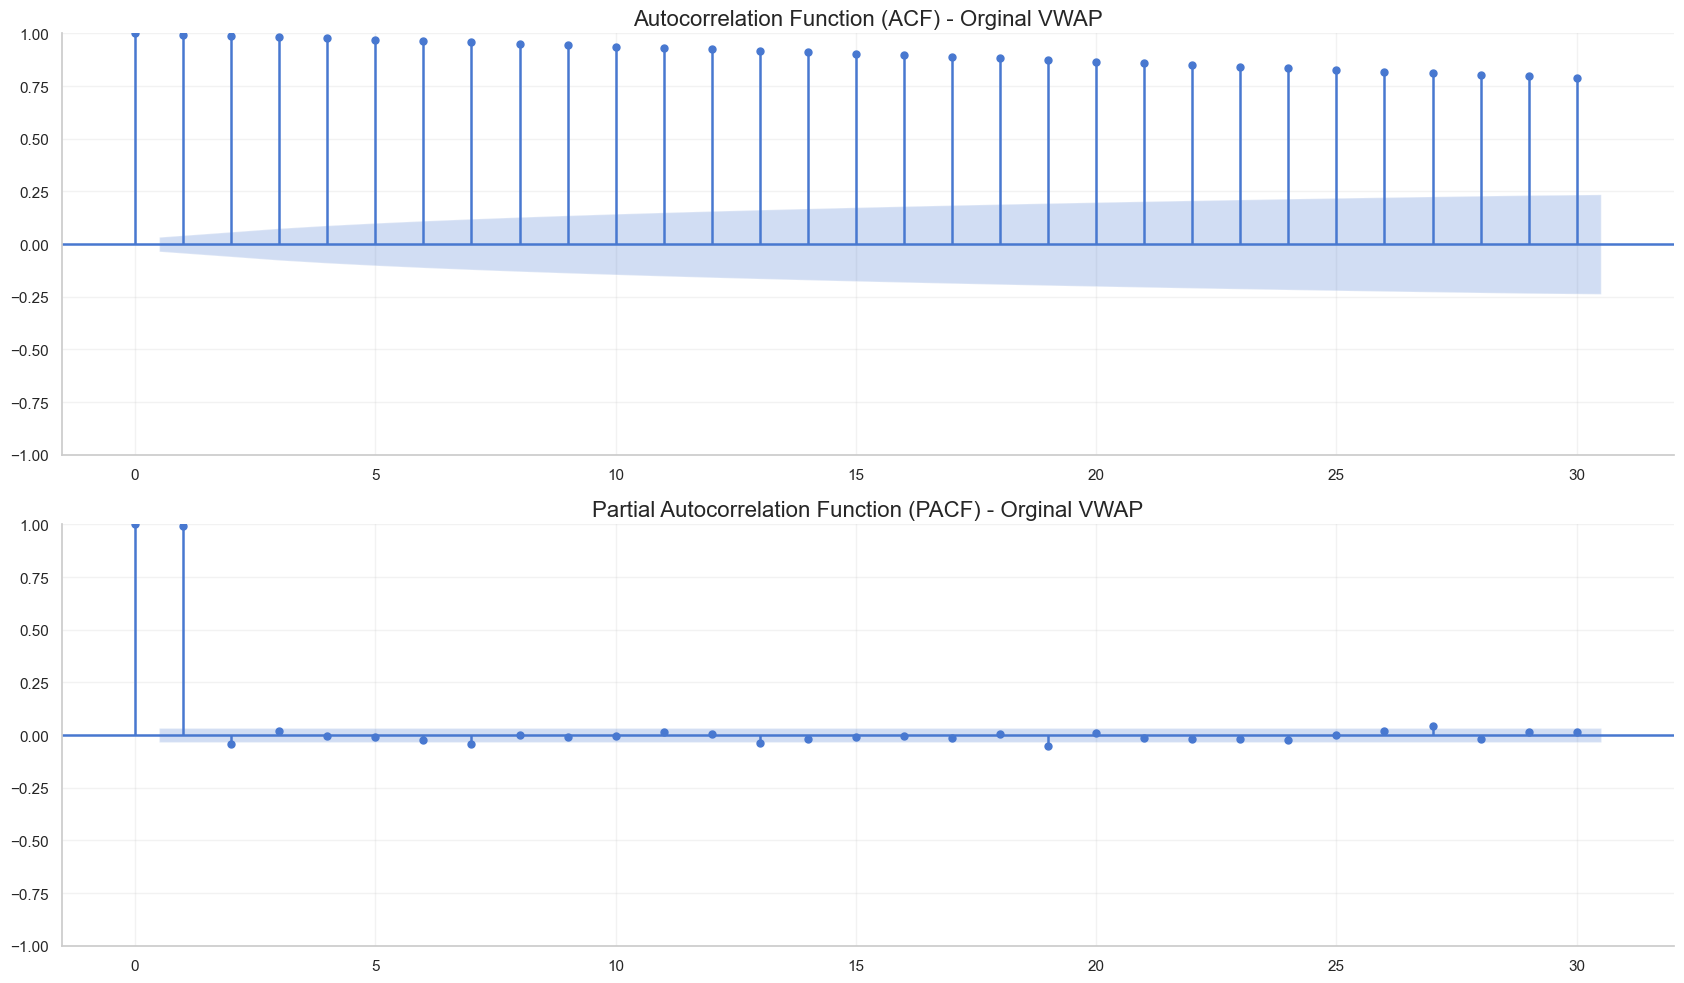

In [57]:
# Creating a DataExplorer object and running a full exploratory analysis pipeline

explore = (DataExplorer(Data)
          .set_caption(caption = 'Orginal VWAP')
          .plot_time_series()
          .plot_rolling_mean_std()
          .plot_box_hist()
          .outlier_report()
          .plot_decomposition(model = 'additive')
          .ACF_and_PACF()  
           )

In [58]:
# Count the number of missing values

explore = explore.check_missing_values()

Missing values in Orginal VWAP data: 0


# **2- Data Prepration**

## DataPrepration Class Definition

*This class extends `DataExplorer` and provides preprocessing tools for time series data before modeling. It includes methods for handling outliers, scaling values, applying transformations, removing seasonality, testing stationarity, and adjusting data for stock split events.*

### Available Methods and Property

- `result`  
  Returns a copy of the processed data.

- `clipping()`  
  Caps extreme values using the IQR method.

- `normalization()`  
  Scales the data using either Min-Max normalization or Standard scaling.

- `log_transform()`  
  Applies a logarithmic transformation to the data.

- `apply_boxcox()`  
  Applies the Box-Cox transformation and stores the optimal lambda.

- `apply_seasonal_diff()`  
  Applies seasonal differencing to remove repeating seasonal effects.

- `ADF()`  
  Performs the Augmented Dickey-Fuller test to check whether the series is stationary.

- `adjust_stock_split()`  
  Adjusts historical values before a stock split date based on the given split ratio.


In [59]:
class DataPrepration(DataExplorer):
    
    def __init__(self, data ):

        # Initialize the parent class with a copy of the input data
        # to avoid modifying the original dataset directly.

        super().__init__(data.copy())

        # Store transformation-related parameters for later reference.
        
        self.boxcox_lambda = None
        self.data_before_diff = None
        self.scaler = None
        self.period = None
        
# *************************************************************************************
    
    @property
    def result(self):

        # Return a copy of the processed data.

        return self.data.copy()

# *************************************************************************************
     
    def clipping(self , threshold=1.5):
        # Cap extreme values using the IQR rule.
        
        q1 = self.data.quantile(0.25)
        q3 = self.data.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - threshold * iqr
        upper_bound = q3 + threshold * iqr
        self.data = self.data.clip(lower_bound, upper_bound)
        
        return self
         
# ************************************************************************************* 
    
    def normalization(self , method = 'minmax'):

         # Scale the data using either Min-Max scaling or Standard scaling.
        
        if method == 'minmax':
            scaler = MinMaxScaler()
        elif method == 'standard':
            scaler = StandardScaler()
        else:
            raise ValueError("method must be either 'minmax' or 'standard'.")
        scaled_data = scaler.fit_transform(self.data.values.reshape(-1, 1))

        # Convert the scaled output back to a pandas Series
        # while preserving the original index.
        
        self.data = pd.Series(scaled_data.flatten(), index=self.data.index)
        return self
        
# *************************************************************************************
    
    def log_transform(self):
        # Apply logarithmic transformation to reduce skewness
        # and stabilize variance.
        
        self.data = np.log(self.data)

        return self
        
# *************************************************************************************
    
    def apply_boxcox(self):

        # Apply Box-Cox transformation and store the optimal lambda value.
        
        fitted_data, fitted_lambda = stats.boxcox(self.data)

        self.boxcox_lambda = fitted_lambda
        
        print('-' * 50)
        print(f"{' ':5} Optimal Lambda for Box-Cox: {fitted_lambda:.4f}")
        print('-' * 50)

        self.data = pd.Series(fitted_data, index=self.data.index)
    
        return self
        
# *************************************************************************************
    
    def apply_seasonal_diff(self, period):

        # Apply seasonal differencing to remove repeating seasonal patterns.

        print(f"Applying Seasonal Differencing (Periods={period })...")

        if period < 1:
            raise ValueError("period must be >= 1")

        self.period = period

        # Keep a copy of the original data before differencing.

        self.data_before_diff = self.data.copy()

        # Subtract each observation from its seasonal lag value.
        
        self.data = self.data - self.data.shift(periods=period )
        self.data.dropna(inplace=True)
    
        return self
        
# *************************************************************************************

    def ADF(self):

        # Run the Augmented Dickey-Fuller test to check stationarity.

        result = adfuller(self.data)
        result_dict = pd.Series(result[0:4], index=['ADF Statistic', 'p-value', 'n_lags', 'n_obs'])

         # Add critical values to the result table.
        
        for key, value in result[4].items():
            result_dict[f'Critical Value ({key})'] = value

        df_result = pd.DataFrame(result_dict, columns=['Value'])
        
        styled_df = df_result.style.set_caption(f'ADF Test Results - {self.caption}')
        display(styled_df)

        p_value = result[1]
        adf_stat = result[0]
        critical_5 = result[4]['5%']

        # Print an interpretable conclusion based on the test result.

        print("\nConclusion:")
        if p_value < 0.05 and adf_stat < critical_5:
            print(f"Since the P-value ({p_value:.4f}) is less than 0.05 and the ADF Statistic ({adf_stat:.4f}) "
                  f" \n is less than the Critical Value (5%: {critical_5:.4f}), the series is Stationary.")
        else:
            print(f"Since the P-value ({p_value:.4f}) is greater than 0.05 or the ADF Statistic ({adf_stat:.4f}) "
                  f" \n is greater than the Critical Value (5%: {critical_5:.4f}), the series is Not Stationary.")
        return self

# *************************************************************************************

    def adjust_stock_split(self, split_date, ratio=5):

        # Adjust historical values before the stock split date
        # so the series remains consistent over time.
    
        split_date = pd.to_datetime(split_date)
    
        self.data.loc[self.data.index < split_date] = (
        self.data.loc[self.data.index < split_date] / ratio)

         # Show a summary of the stock split adjustment.
        
        result_df = pd.DataFrame({
                                'Event': ['Stock Split Adjustment'],
                                'Split Ratio': [f'{ratio}-for-1'],
                                'Split Date': [split_date.date()],
                                'Adjustment': [f'VWAP before {split_date.date()} were divided by {ratio}']
                                })

        display(result_df)

        return self

In [60]:
# Finding the date and percentage of the largest drop in the series.

pct_change = Data.pct_change()

decline_date = pct_change.idxmin()
drop_percent = pct_change.min()

result_df = pd.DataFrame({
                        'Date of the sharpest decline': [decline_date.date()],
                        'Percentage Drop': [f'{drop_percent : .2%}']
                        })
result_df

,Date of the sharpest decline,Percentage Drop
0,2010-09-23,-80.01%


In [61]:
# printing a one-week window around target date for closer inspection.

target_date = '2010-09-23'
print(Data.loc['2010-09-20':'2010-09-26'])

Date
2010-09-20    848.21
2010-09-21    843.50
2010-09-22    839.84
2010-09-23    167.86
2010-09-24    162.28
Name: VWAP, dtype: float64


### Stock Split Information

The image below shows the stock split event for **ADANIPORTS** on the **National Stock Exchange of India (NSE)**.

| Field | Details |
| --- | --- |
| **Company / Symbol** | Adani Ports (`ADANIPORTS`) |
| **Series** | `EQ` |
| **Purpose** | Face value split from **Rs. 10/- to Rs. 2/-** |
| **Split Ratio** | **5:1** |
| **Ex-Date** | **23-Sep-2010** |
| **Record Date** | **24-Sep-2010** |

This corporate action means that each existing share was split into 5 new shares. For time series analysis, prices before the split date should be adjusted accordingly to keep the series consistent.


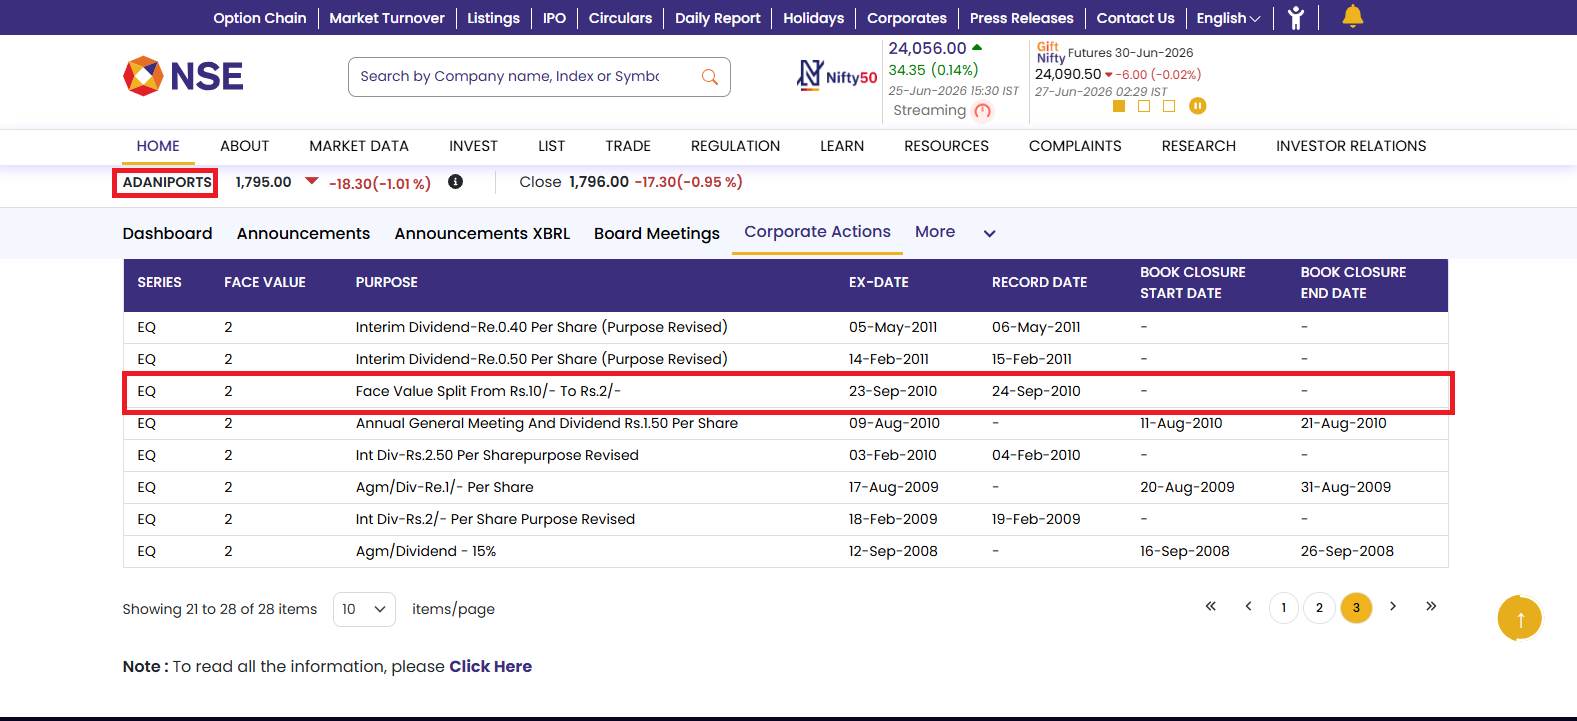

In [62]:
preparation_Data = Data.copy()

,Event,Split Ratio,Split Date,Adjustment
0,Stock Split Adjustment,5-for-1,2010-09-23,VWAP before 2010-09-23 were divided by 5


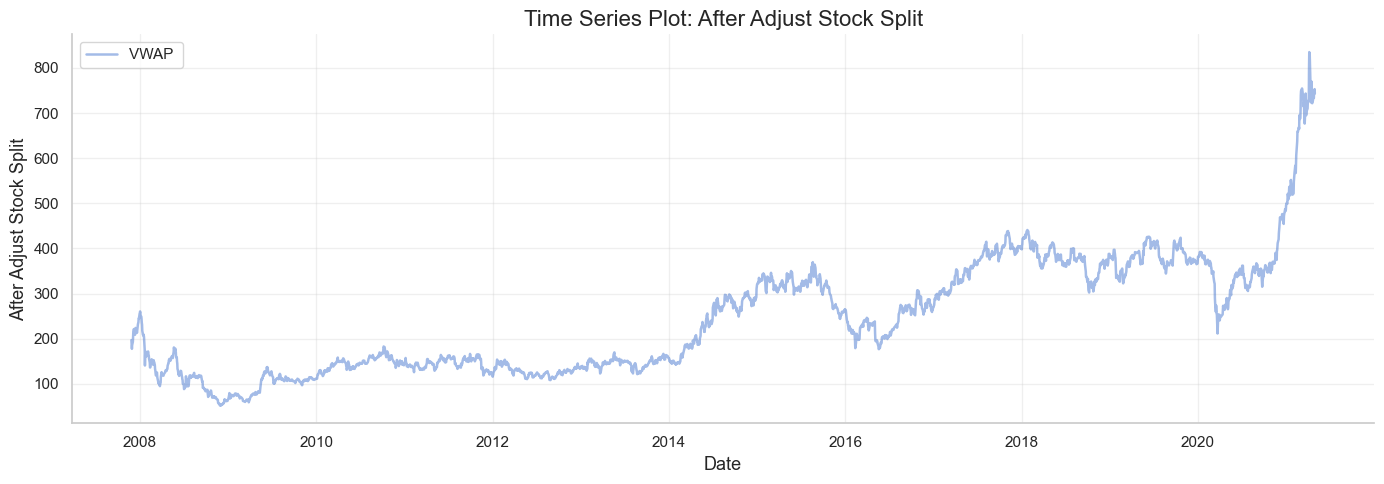

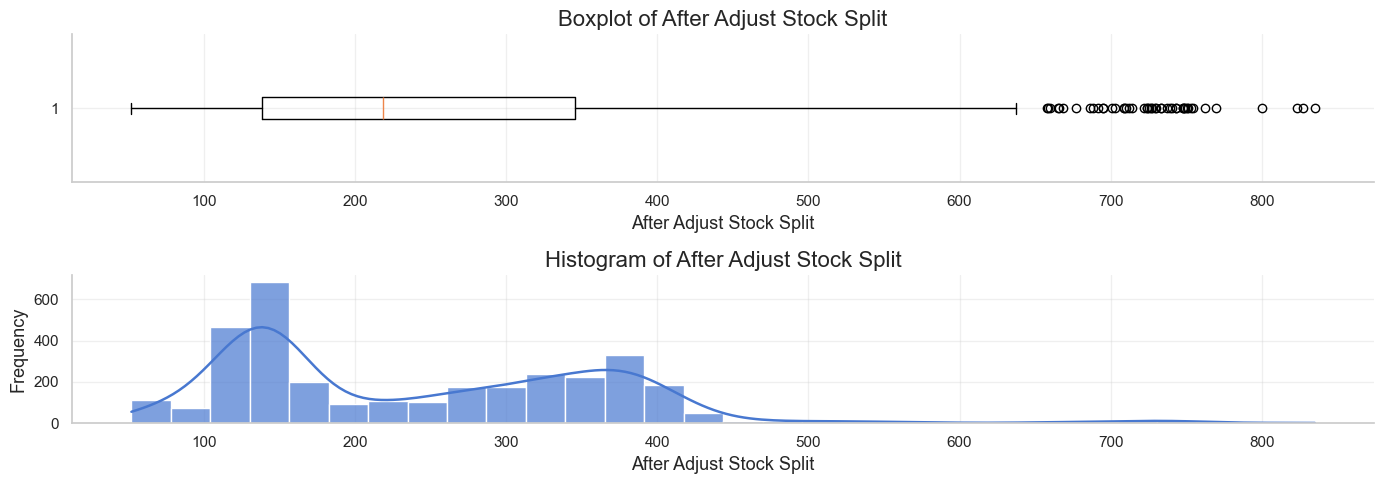

,Metric,Value
0,Threshold,1.500000
1,Q1,138.100000
2,Q3,345.327500
3,IQR,207.227500
4,Lower Bound,-172.741250
5,Upper Bound,656.168750
6,Total Samples,3322.000000
7,Outlier Count,48.000000
8,Outlier Percentage (%),1.440000


In [63]:
# Creating a preprocessing pipeline to adjust the series for the stock split
# and re-evaluating its distribution and outliers after correction.

prepration = (DataPrepration(preparation_Data)
                .set_caption('After Adjust Stock Split')
                .adjust_stock_split(split_date='2010-09-23' , ratio=5)
                .plot_time_series()
                .plot_box_hist()
                .outlier_report()
                )

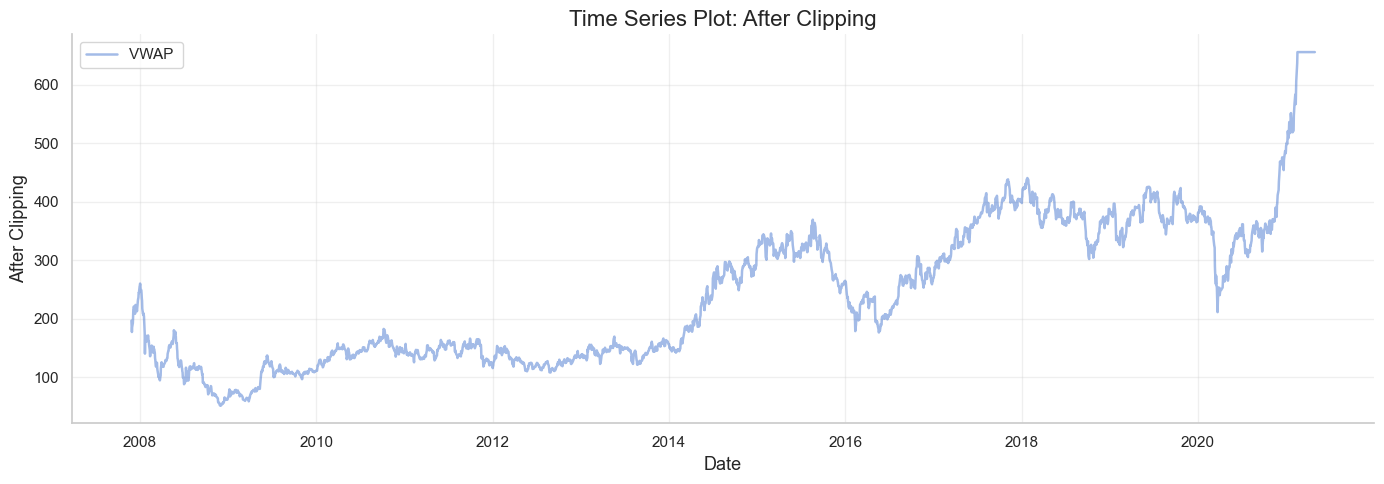

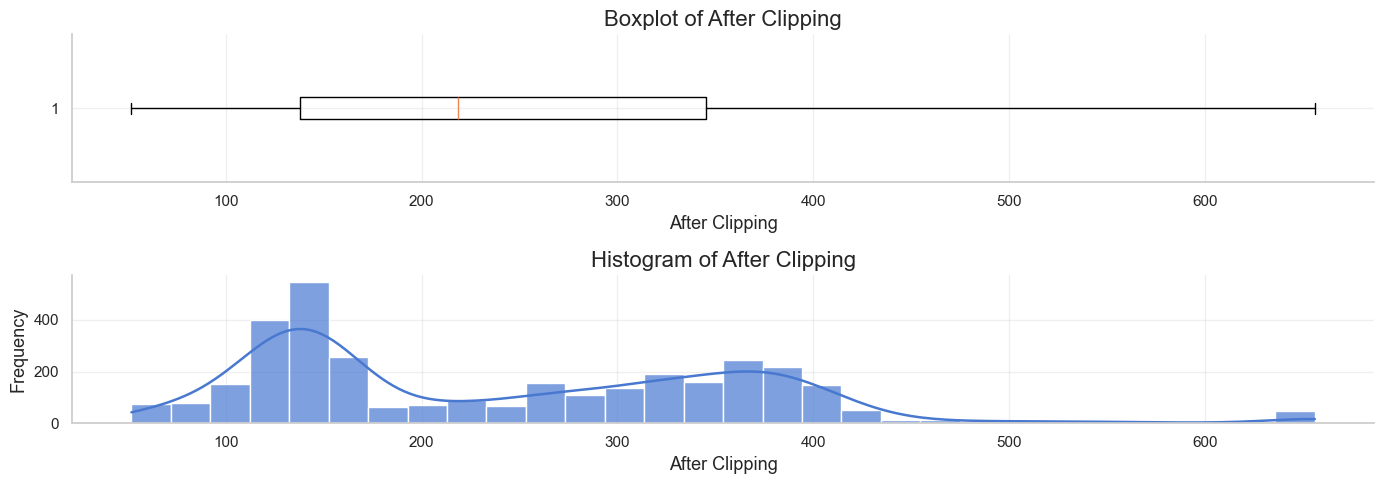

,Metric,Value
0,Threshold,1.500000
1,Q1,138.100000
2,Q3,345.327500
3,IQR,207.227500
4,Lower Bound,-172.741250
5,Upper Bound,656.168750
6,Total Samples,3322.000000
7,Outlier Count,0.000000
8,Outlier Percentage (%),0.000000


,Value
ADF Statistic,0.483035
p-value,0.984348
n_lags,13.000000
n_obs,3308.000000
Critical Value (1%),-3.432328
Critical Value (5%),-2.862414
Critical Value (10%),-2.567235



Conclusion:
Since the P-value (0.9843) is greater than 0.05 or the ADF Statistic (0.4830)  
 is greater than the Critical Value (5%: -2.8624), the series is Not Stationary.


In [64]:
# Data Cleaning Pipeline:
# 1. Applying clipping to handle remaining outliers
# 2. Visualizing the distribution after cleaning
# 3. Checking for stationarity using the ADF test

prepration = (prepration
                .set_caption('After Clipping')
                .clipping()
                .plot_time_series()
                .plot_box_hist()
                .outlier_report()
                .ADF()
                )
    

--------------------------------------------------
      Optimal Lambda for Box-Cox: 0.1430
--------------------------------------------------


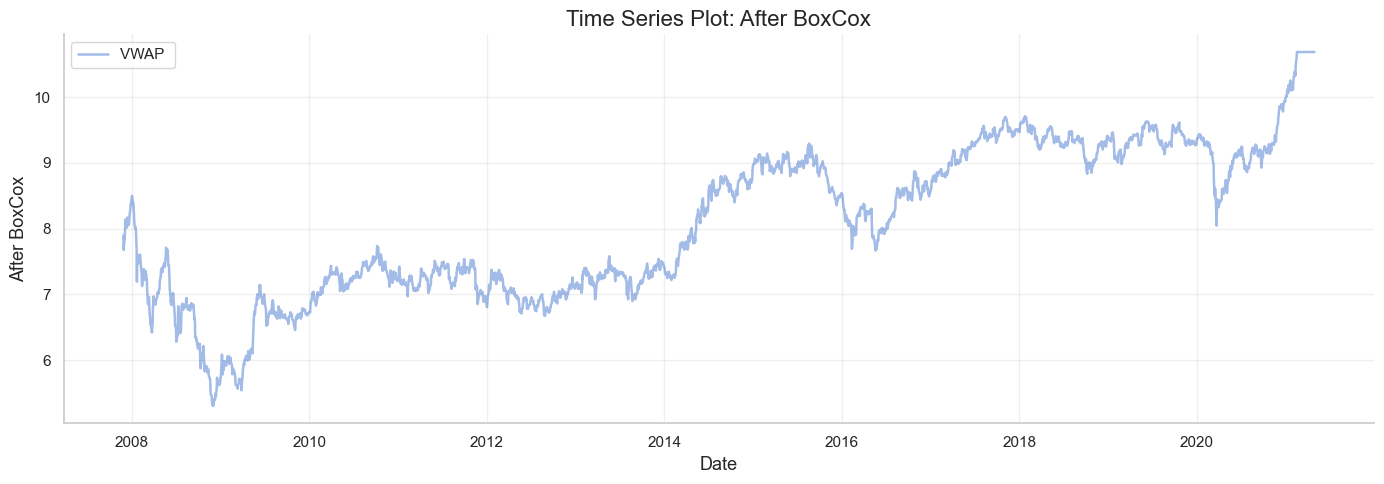

,Value
ADF Statistic,-0.604994
p-value,0.869849
n_lags,1.000000
n_obs,3320.000000
Critical Value (1%),-3.432321
Critical Value (5%),-2.862411
Critical Value (10%),-2.567234



Conclusion:
Since the P-value (0.8698) is greater than 0.05 or the ADF Statistic (-0.6050)  
 is greater than the Critical Value (5%: -2.8624), the series is Not Stationary.


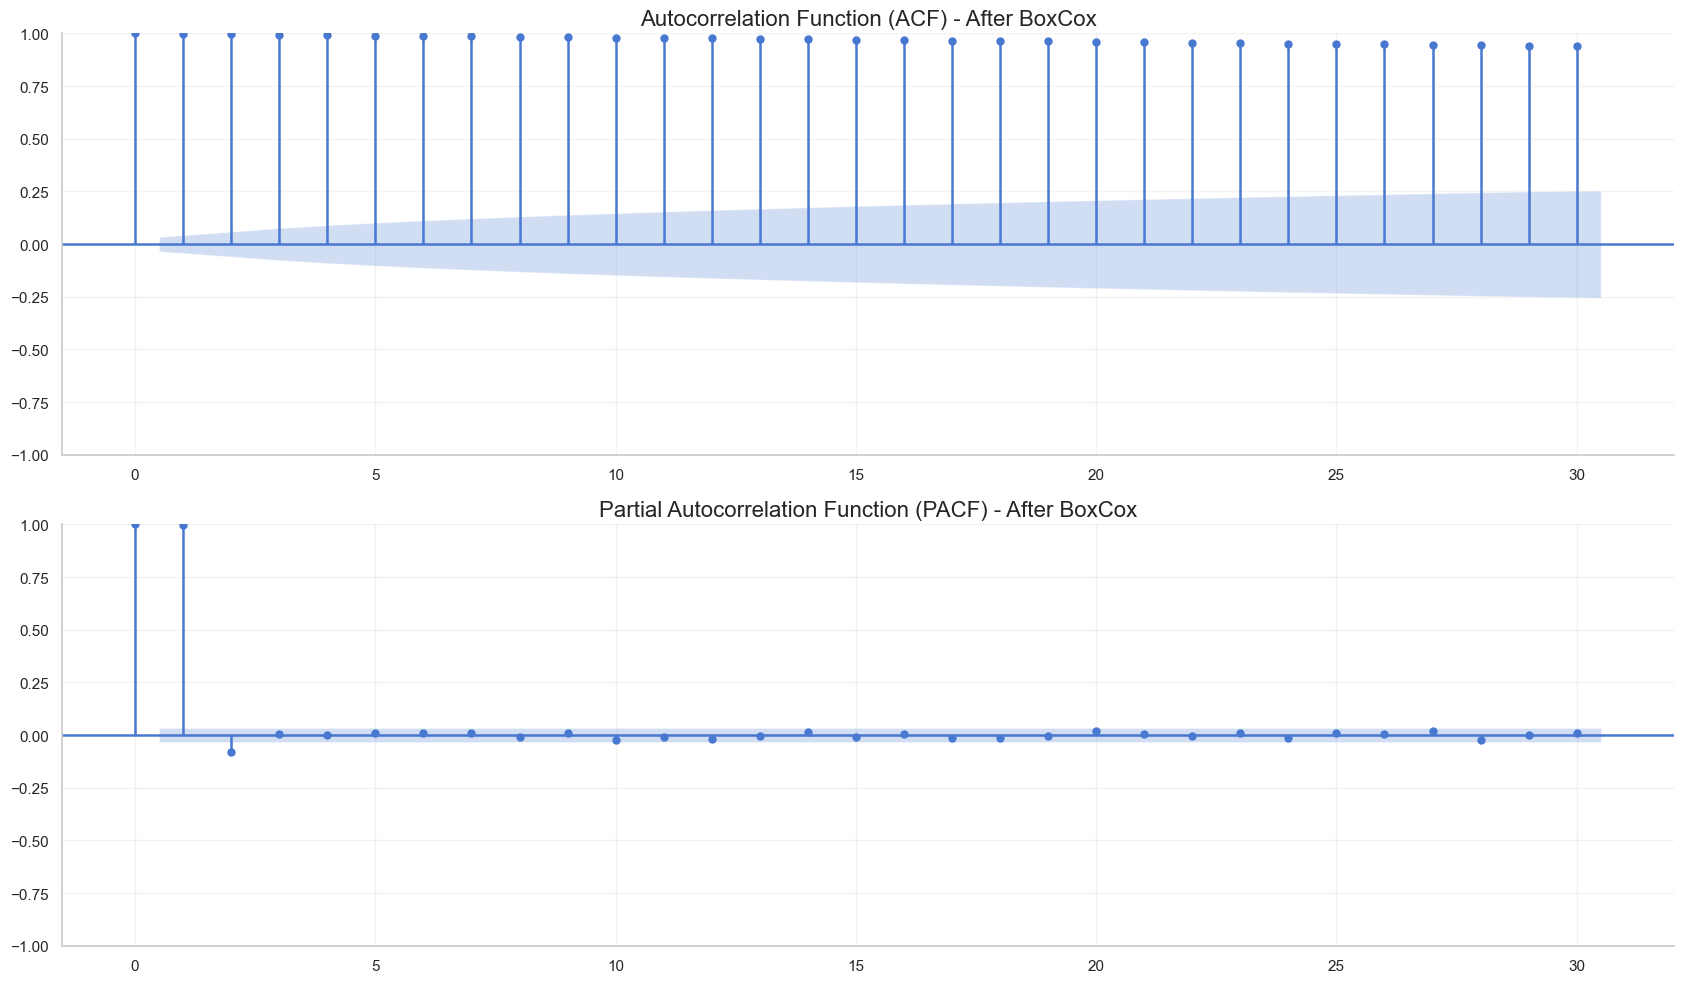

In [65]:
# Box-Cox preprocessing pipeline:
# 1. Applying Box-Cox transformation to stabilize variance.
# 2. Plotting the transformed time series.
# 3. Checking stationarity using the ADF test.
# 4. Examining autocorrelation structure with ACF and PACF.

prepration = (prepration
                    .apply_boxcox()
                    .set_caption('After BoxCox')
                    .plot_time_series()
                    .ADF()
                    .ACF_and_PACF()
                     )

Applying Seasonal Differencing (Periods=1)...


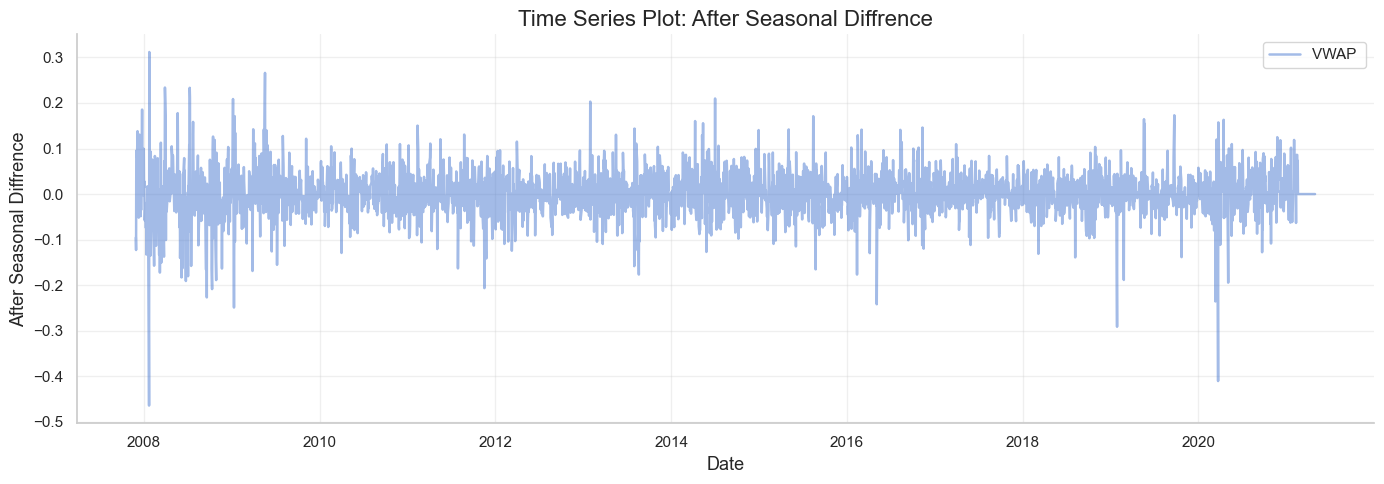

,Value
ADF Statistic,-50.032860
p-value,0.000000
n_lags,0.000000
n_obs,3320.000000
Critical Value (1%),-3.432321
Critical Value (5%),-2.862411
Critical Value (10%),-2.567234



Conclusion:
Since the P-value (0.0000) is less than 0.05 and the ADF Statistic (-50.0329)  
 is less than the Critical Value (5%: -2.8624), the series is Stationary.


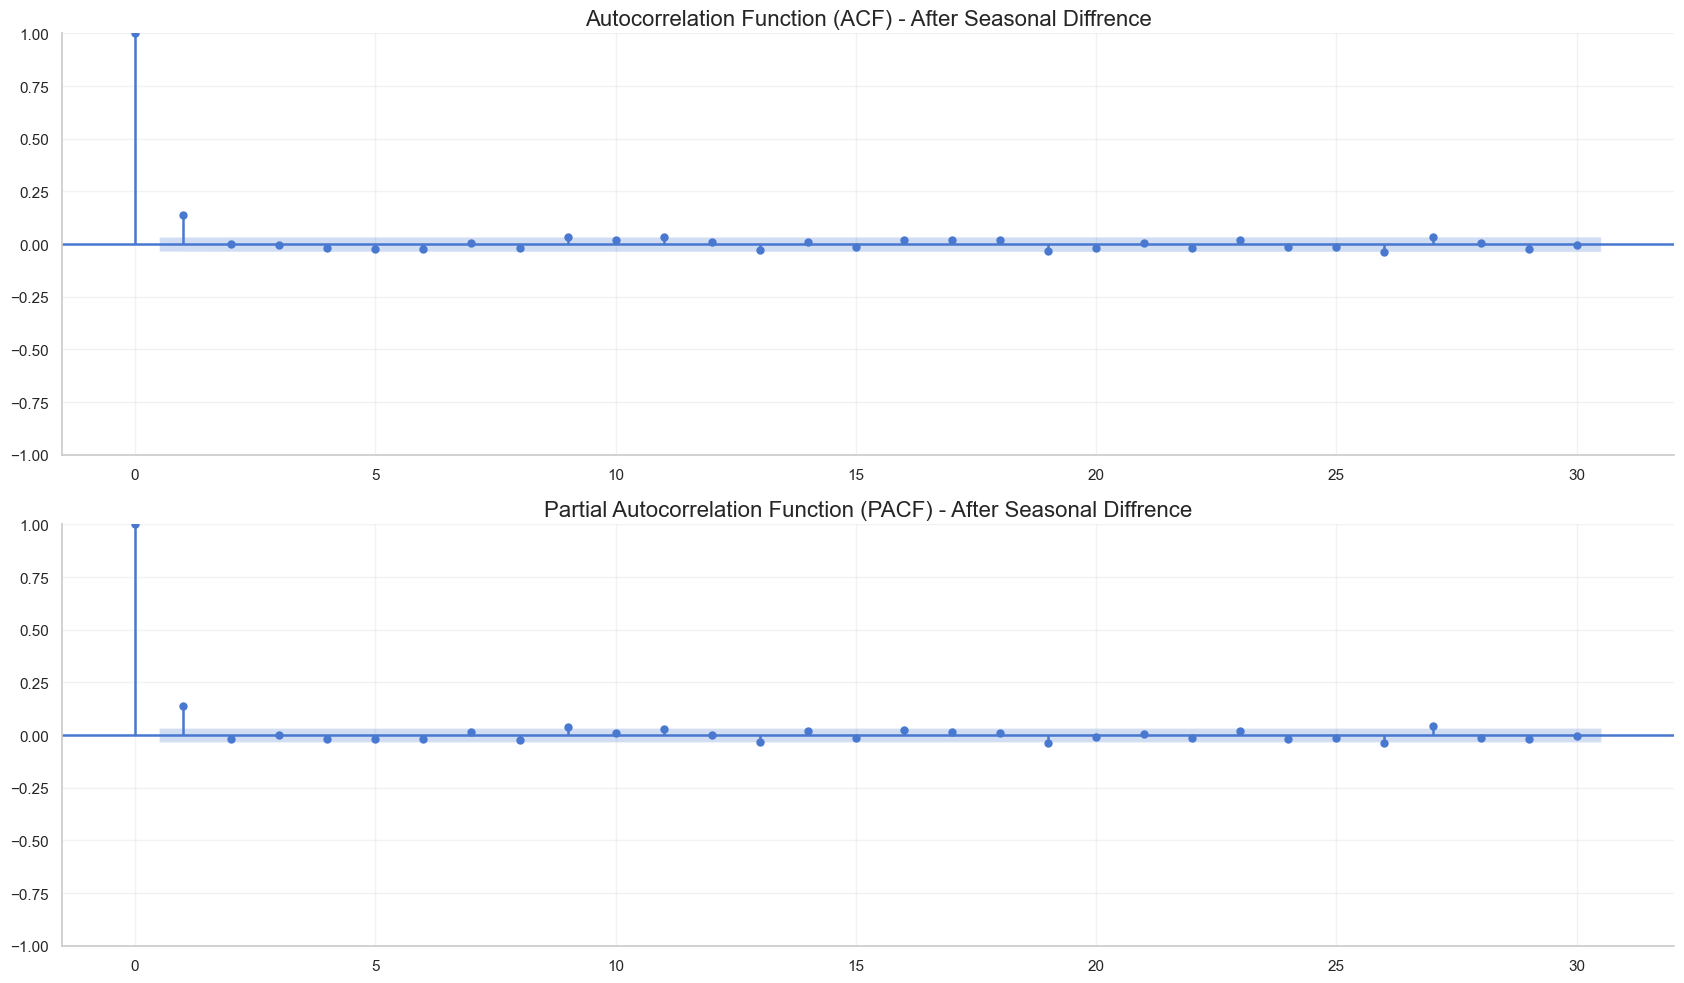

In [66]:
# Seasonal differencing preprocessing pipeline:
# 1. Applying seasonal differencing with a lag of 1 to remove short-term trend.
# 2. Plotting the transformed time series.
# 3. Checking stationarity using the ADF test.
# 4. Examinnig autocorrelation structure with ACF and PACF.

prepration = (prepration
                .apply_seasonal_diff(period = 1)
                .set_caption('After Seasonal Diffrence')
                .plot_time_series()
                .ADF()
                .ACF_and_PACF()
                 )

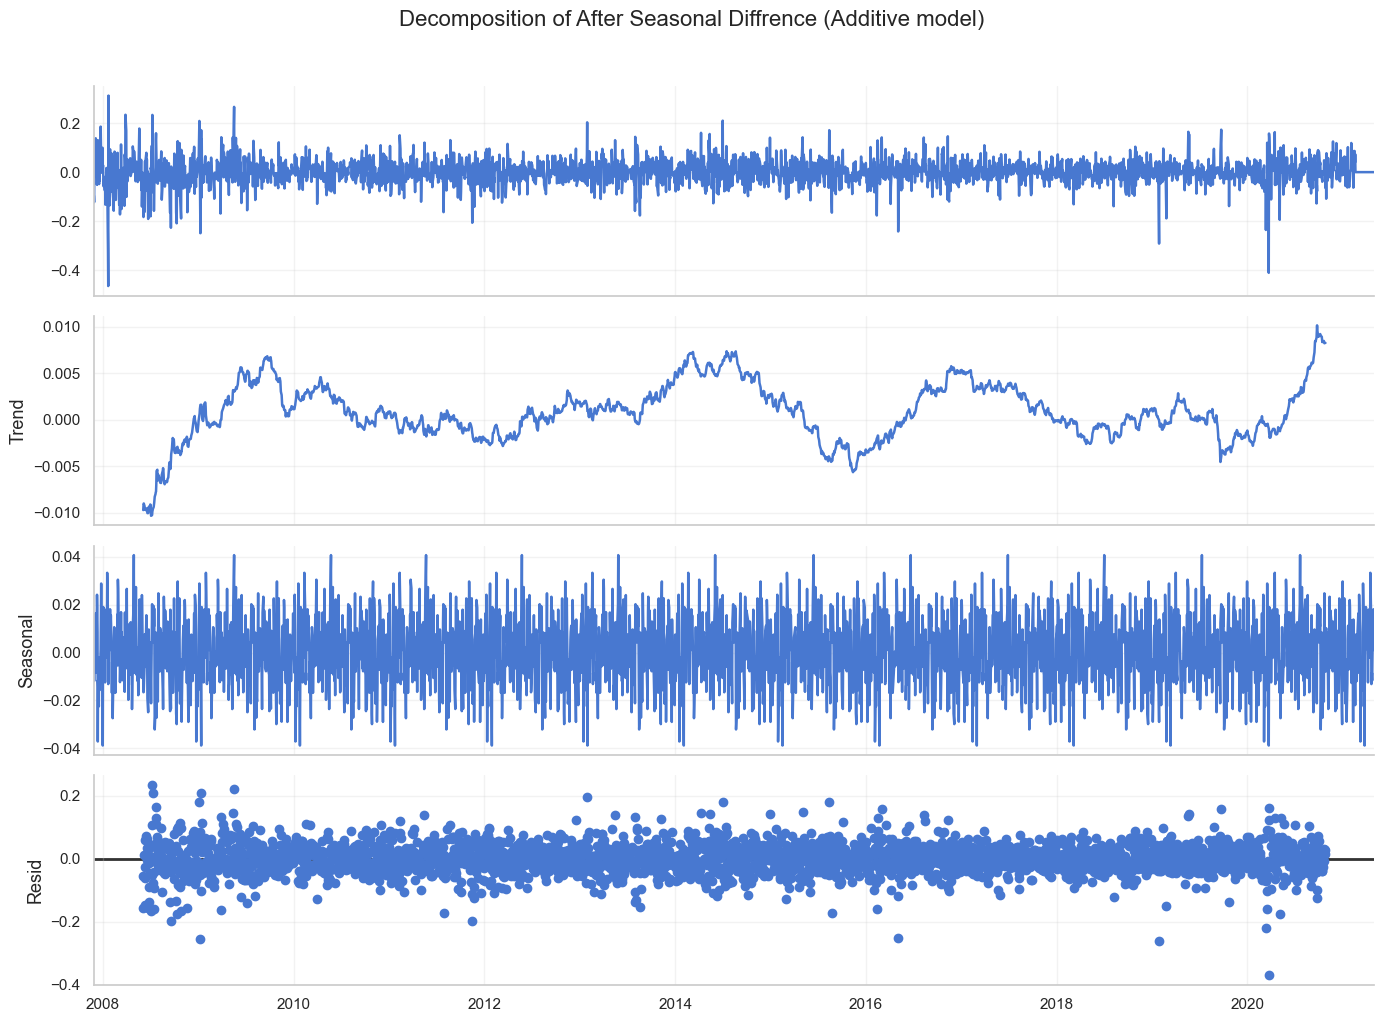

In [67]:
#Extracting and visualizing the trend, seasonality, and noise from the preprocessed data.

prepration = (prepration.plot_decomposition())

In [68]:
# Storing the prepared data and present it as a labeled DataFrame.

clean_data = prepration.result
pd.DataFrame(clean_data , columns = ['VWAP after Preparation'])

,VWAP after Preparation
Date,
2007-11-28,-0.095510
2007-11-29,-0.122745
2007-11-30,0.095157
2007-12-03,0.081526
2007-12-04,0.107007
...,...
2021-04-26,0.000000
2021-04-27,0.000000
2021-04-28,0.000000


# **3- Modeling**

## Modeling Class Definition

*This class is designed to manage the modeling stage of a time series forecasting workflow. It supports both statistical and deep learning approaches, including ARIMA and RNN models. It also provides methods for splitting data, preparing sequential windows, training models, generating forecasts, reversing transformations, validating predictions, and evaluating model performance.*

### Available Methods

- `train_test_split()`  
  Splits the time series into training and testing sets. For RNN models, it also creates sliding input-output windows based on the specified step size.

- `build_fit_rnn_model()`  
  Builds and trains a SimpleRNN model using the prepared training windows, with support for callbacks such as early stopping, learning rate reduction, and TensorBoard logging.

- `arima_model()`  
  Fits an ARIMA model to the training data using the specified `(p, d, q)` order.

- `auto_arima()`  
  Automatically searches for a suitable ARIMA configuration within the given parameter ranges.

- `grid_search_arima()`  
  Performs a manual grid search over different ARIMA orders and ranks them using model selection criteria such as AIC and BIC.

- `forecast()`  
  Generates forecasts using the fitted ARIMA or RNN model on the test data.

- `inverse_transform()`  
  Reverses preprocessing transformations such as seasonal differencing and Box-Cox transformation to restore predicted values to the original scale.

- `plot_validation()`  
  Plots the training data, actual test data, and forecasted values for visual comparison.

- `evaluate()`  
  Measures forecast accuracy using evaluation metrics such as MAE and RMSE.

- `__make_windows()`  
  A private helper method that converts a time series into overlapping input-output sequences for RNN training.


In [69]:
class Modeling:
    
    def __init__(self, data , prep=None):

        # Storing a copy of the input data to avoid modifying the original series.
        
        self.data = data.copy()

        # Keeping a reference to the preprocessing object for inverse transformations
        
        self.prep = prep

        # Holding train/test splits for classical time series modeling.

        self.train_data = None
        self.test_data = None

        # Holding windowed train/test sets for RNN models.
        
        self.X_train = None
        self.y_train = None
        self.X_test = None
        self.y_test = None

        # Storing fitted ARIMA and RNN models separately.

        self.fitted_model = None
        self.rnn_fitted_model = None

        # Storing training history and the RNN window size.

        self.history = None
        self.rnn_step = None

# *************************************************************************************
        
    def __make_windows(self, data, step):

        # Convert a 1D time series into overlapping input-output windows
        # for sequence learning models such as RNN.
        
        X, y = [], []
        
        values = np.array(data).reshape(-1, 1)

        for i in range(len(values) - step):
            X.append(values[i:i+step])
            y.append(values[i+step])

        return np.array(X), np.array(y)

# *************************************************************************************

    def train_test_split(self , model_type , train_size=0.8 , step=None):

        # Split the data into training and testing sets.
        # If the model is RNN, also generate sliding windows.

        model_type = model_type.upper().strip()

        if not 0 < train_size < 1:
            raise ValueError("train_size must be between 0 and 1")

        split_idx = int(len(self.data)*train_size)
    
        self.train_data = self.data[: split_idx]
        self.test_data = self.data[split_idx :]
        
        if model_type == 'ARIMA':
            
            # For ARIMA, only the raw train/test split is needed.
            report = {'Model Type': 'ARIMA',
                        'Sample Size' : len(self.data),
                        'Train Size' : len(self.train_data),
                        'Test Size': len(self.test_data)
                    }
            
            display(pd.DataFrame([report] ).T)
            
        elif model_type == 'RNN':
            
            # For RNN, build sequential windows from train/test data.
            if not isinstance(step,int) or step <= 0:
                raise ValueError("step must be a positive integer when model_type='RNN'")  
                
            self.rnn_step = step
            
            self.X_train, self.y_train = self.__make_windows(self.train_data, step)
            self.X_test, self.y_test = self.__make_windows(self.test_data, step)
            
            report = {'Model Type': 'RNN',
                      'Step': step,
                      'X_train shape': (self.X_train.shape),
                      'y_train shape': (self.y_train.shape),
                      'X_test shape':  (self.X_test.shape),
                      'y_test shape':  (self.y_test.shape)
                    }
            
            display(pd.DataFrame([report] ).T)
            
        else:
             raise ValueError("model_type must be either 'ARIMA' or 'RNN'.")
            
        return self

# *************************************************************************************

    def build_fit_rnn_model(self , 
                            units=64 , 
                            loss='mean_squared_error', 
                            optimizer='rmsprop' , 
                            epochs = 100 , 
                            batch_size=16,
                            validation_split=0.1):

        # Building and training a simple RNN model for forecasting.
        # Includes TensorBoard logging, early stopping, and learning-rate reduction.
        
        
        log_dir = os.path.join("logs", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
        
        tensorboard = TensorBoard(log_dir=log_dir,
                                    histogram_freq=1,
                                    write_graph=True
                                    )

        early_stop = EarlyStopping(monitor='val_loss',
                                    patience=5,
                                    restore_best_weights=True
                                    )

        reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                                        factor=0.2,
                                        patience=2,
                                        min_lr=0.00001
                                        )
        my_callbacks = [early_stop , reduce_lr, tensorboard]

         # Creating a simple single-layer RNN followed by a dense output layer.   
        self.rnn_fitted_model=Sequential()
        self.rnn_fitted_model.add(SimpleRNN(units=units , 
                                            input_shape=(self.X_train.shape[1], self.X_train.shape[2]) , 
                                            activation="tanh"
                                            )
                                 )
        
        self.rnn_fitted_model.add(Dense(1))
        
        # Compiling the model with the selected loss and optimizer.
        self.rnn_fitted_model.compile(loss=loss,optimizer=optimizer)

        self.rnn_fitted_model.summary()
        
        # Training the model and keep the training history.
        history = self.rnn_fitted_model.fit(self.X_train,
                                            self.y_train,
                                            epochs=epochs,
                                            batch_size=batch_size,
                                            validation_split=validation_split,
                                            verbose=2,
                                            callbacks=my_callbacks
                                            )

        return self

# *************************************************************************************
        
    def arima_model(self , order):

        # Fiting an ARIMA model with the specified (p, d, q) order.

        if any(i < 0 for i in order):
            raise ValueError("All parameters must be greater than or equal 0")
        
        arima = ARIMA(self.train_data, order = order)
        
        self.fitted_model = arima.fit()
        
        display(self.fitted_model.summary())

        return self.fitted_model

# *************************************************************************************

    def auto_arima(self , start_p=0 , start_q=0 , max_p=5 , max_q=5):

        # Automatically search for a suitable ARIMA configuration
        # within the specified p and q ranges
        
        auto_model = pm.auto_arima( y = self.train_data ,
                                    d=0,             
                                    start_p=start_p,       
                                    start_q=start_q,       
                                    max_p=max_p,        
                                    max_q=max_q,         
                                    seasonal=False,  
                                    trace=True,      
                                    error_action='ignore',
                                    suppress_warnings=True,
                                    stepwise=True   
                                    )
        
        display(auto_model.summary())
        
        return auto_model
        
# *************************************************************************************

    def grid_search_arima(self , max_p=5, max_q=5, d=0):

        # Perform a manual grid search over ARIMA hyperparameters
        # and rank the fitted models using AIC.
        
        if (max_p or max_q) <= 0 :
            raise ValueError(" max_p and max_q must be greater than 0")
            
        p = range(0, max_p + 1)
        q = range(0, max_q + 1)
    
        combinations = list(itertools.product(p, [d], q))
    
        results = []
    
        for order in combinations:

            try:
                model = ARIMA(self.train_data, order=order).fit()
    
                results.append({
                    "order": order,
                    "AIC": model.aic,
                    "BIC": model.bic
                })
    
            except:
                continue

        results_df = pd.DataFrame(results)
    
        results_df = results_df.sort_values("AIC")
    
        display(results_df.head())
    
        best_order = results_df.iloc[0]["order"]
    
        print("Best order:", best_order)
    
        return best_order, results_df
        
# *************************************************************************************
        
    def forecast(self, model_type , steps=None):

         # Generating forecasts using the fitted ARIMA or RNN model.

        model_type = model_type.upper().strip()

        if model_type == 'ARIMA':
            
            if self.fitted_model is None:
                raise ValueError("Model is not fitted yet. Call arima_model() first.")
            if steps is None:
                steps = len(self.test_data)
                
            arima_preds = self.fitted_model.forecast(steps=steps)
            forecast=pd.Series(np.asarray(arima_preds),
                                index =self.test_data.index[:steps],
                                name =' forecast' )
            
        elif model_type == 'RNN':
            if self.rnn_fitted_model is None:
                raise ValueError("RNN model is not fitted yet. Call build_fit_rnn_model() first.") 
            if self.X_test is None:
                raise ValueError("Test windows are not created. Call train_test_split(model_type='RNN', step=...) first.")
    
            rnn_preds = self.rnn_fitted_model.predict(self.X_test, verbose=0) 
            forecast = pd.Series(rnn_preds.ravel(),
                                 index=self.test_data.index[self.rnn_step:],
                                 name =' forecast')  
            
        else:           
            raise ValueError("model_type must be either 'ARIMA' or 'RNN'.")  
            
        return forecast
        
# *************************************************************************************    

    def inverse_transform(self, transformed_data):

        # Reverse preprocessing steps such as seasonal differencing
        # and Box-Cox transformation to bring forecasts back to original scale.
     
        period = self.prep.period
        restored = transformed_data.copy()

        if period>0 :
            anchor = self.prep.data_before_diff.shift(period).loc[transformed_data.index]  
            restored = anchor.add(transformed_data ,fill_value=0)

        if self.prep.boxcox_lambda is not None:
            restored = inv_boxcox(restored, self.prep.boxcox_lambda)            
   
        return restored

# *************************************************************************************  

    def plot_validation(self, 
                        train , 
                        test , 
                        forcast , 
                        forecast_lable='forecast', 
                        title='Time Series Validation'
                       ):

        # Ploting training data, actual test data, and model forecasts
        # for visual comparison.

        colors = {'train': '#4A4E69', 'test': '#2A9D8F', 'forecast': '#E76F51'}
        plt.figure(figsize=(14, 7))
    
        plt.plot(train.index, train, label='Train (Original)',
                 color=colors['train'], alpha=0.4, linewidth=1.5)

        plt.plot(test.index, test, label='Test (Actual)',
                 color=colors['test'], linewidth=2.5)

        plt.plot(forcast.index, forcast, label=forecast_lable,
                 color=colors['forecast'], linestyle='--', linewidth=2.5)

        plt.title(title, fontsize=16, fontweight='bold', pad=15)
        plt.grid(True, linestyle='--', alpha=0.3)
        plt.legend(fontsize=12, frameon=True, shadow=True)
    
        ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        plt.tight_layout()
        plt.show()
  
        return self

# *************************************************************************************  

    def evaluate(self , pred , model_type ):

        # Evaluate forecast accuracy using MAE and RMSE.

        model_type = model_type.upper().strip()

        if model_type == 'ARIMA':
            actual = self.test_data

        elif model_type == 'RNN':
            if self.rnn_step is None:
                raise ValueError("RNN step is not set. Call train_test_split(model_type='RNN', step=...) first.")
            actual = self.test_data[self.rnn_step:]
        else:
            raise ValueError("model_type must be either 'ARIMA' or 'RNN'.")      

        # The alignment step ensures that actual and predicted values
        # are compared only on shared indices.

        actual, predicted = actual.align(pred, join='inner')
        
        mae = mean_absolute_error(actual, predicted)
        rmse = np.sqrt( mean_squared_error(actual, predicted) )

        report = {
                    'Model Type': model_type,
                    'MAE': mae,
                    'RMSE':rmse}
            
        return display(pd.DataFrame([report] ).T)       

## Scenario 1 – Modeling with ARIMA algorithm

In [44]:
# Creating the modeling object using the prepared data.
# and keeping the preprocessing reference for restoring forecasts later.

first_model = Modeling(data=clean_data , prep=prepration)

In [45]:
# Split the time series into training and testing sets for ARIMA modeling.

first_model.train_test_split(model_type='ARIMA')

,0
Model Type,ARIMA
Sample Size,3321
Train Size,2656
Test Size,665


- AR Model

In [46]:
# Fit an AR model with the specified (p, d, q) order.

ar_model = first_model.arima_model( order=(2,0,0) )

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2656
Model:                 ARIMA(2, 0, 0)   Log Likelihood                4163.259
Date:                Fri, 17 Jul 2026   AIC                          -8318.518
Time:                        16:13:45   BIC                          -8294.979
Sample:                             0   HQIC                         -8309.998
                               - 2656                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.460      0.646      -0.002       0.003
ar.L1          0.1619      0.011     15.320      0.000       0.141       0.183
ar.L2         -0.0228      0.015     -1.567      0.117      -0.051       0.006
sigma2         0.0025   3.66e-05     69.600      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):              3319.73
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.46   Skew:                            -0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

- MA Model

In [47]:
# Fit an MA model with the specified (p, d, q) order.

ma_model = first_model.arima_model( order=(0,0,2) )

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2656
Model:                 ARIMA(0, 0, 2)   Log Likelihood                4163.237
Date:                Fri, 17 Jul 2026   AIC                          -8318.474
Time:                        16:13:51   BIC                          -8294.935
Sample:                             0   HQIC                         -8309.955
                               - 2656                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.454      0.650      -0.002       0.003
ma.L1          0.1635      0.011     15.555      0.000       0.143       0.184
ma.L2          0.0047      0.013      0.352      0.725      -0.021       0.031
sigma2         0.0025   3.66e-05     69.515      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3319.78
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.46   Skew:                            -0.14
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.47
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

- Tuning parameters with Auto ARIMA

In [23]:
# Automatically searching for the best ARIMA configuration within the given p and q ranges.

auto_model = first_model.auto_arima(start_p=0, start_q=0, max_p=5, max_q=5)

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8254.102, Time=0.11 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-8320.930, Time=0.11 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-8322.189, Time=0.17 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-8320.247, Time=0.21 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-8320.252, Time=0.18 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-8318.244, Time=0.36 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-8320.416, Time=0.32 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0]          
Total fit time: 1.463 seconds


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2656
Model:               SARIMAX(0, 0, 1)   Log Likelihood                4163.095
Date:                Thu, 09 Jul 2026   AIC                          -8322.189
Time:                        11:44:20   BIC                          -8310.420
Sample:                             0   HQIC                         -8317.929
                               - 2656                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.1637      0.010     16.410      0.000       0.144       0.183
sigma2         0.0025   3.62e-05     70.332      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3306.87
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.46   Skew:                            -0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

- Tuning parameters with GridSearch

In [24]:
# Searching for the best ARIMA order using grid search.

best_order, results_grid_search = first_model.grid_search_arima( max_p=5, max_q=5)

,order,AIC,BIC
30,"(5, 0, 0)",-8320.858156,-8279.666120
1,"(0, 0, 1)",-8320.413739,-8302.760009
5,"(0, 0, 5)",-8320.212625,-8279.020589
28,"(4, 0, 4)",-8319.983894,-8261.138129
6,"(1, 0, 0)",-8319.142195,-8301.488465


Best order: (5, 0, 0)


In [37]:
# Fiting an ARIMA model using the best order found by grid search.

gridsearch_model = first_model.arima_model( order=best_order )

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2656
Model:                 ARIMA(5, 0, 0)   Log Likelihood                4167.429
Date:                Thu, 09 Jul 2026   AIC                          -8320.858
Time:                        12:07:53   BIC                          -8279.666
Sample:                             0   HQIC                         -8305.949
                               - 2656                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.489      0.625      -0.002       0.003
ar.L1          0.1621      0.011     15.281      0.000       0.141       0.183
ar.L2         -0.0228      0.015     -1.542      0.123      -0.052       0.006
ar.L3         -0.0013      0.015     -0.083      0.934      -0.031       0.029
ar.L4         -0.0144      0.015     -0.949      0.342      -0.044       0.015
ar.L5         -0.0511      0.016     -3.219      0.001      -0.082      -0.020
sigma2         0.0025   3.65e-05     69.534      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3363.95
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               0.46   Skew:                            -0.17
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

| ویژگی | ARIMA(0,0,1) | ARIMA(5,0,0) |
|---|---|---|
| نوع مدل | MA(1) | AR(5) |
| تعداد پارامترها | کم | زیاد |
| AIC | -9446.989 | -9447.515 |
| BIC | -9429.336 | -9406.323 |
| Ljung-Box p-value | 0.99 | 0.93 |
| Residuals سفید؟ | بله | بله |
| پارامترهای غیرمعنادار | ندارد | چندتا دارد |
| پیچیدگی | بسیار ساده | نسبتاً پیچیده |


The first model, ARIMA(0, 0, 1), is by far the better model.

1- The ARIMA(0, 0, 1) model with only 1 parameter (ma.L1) performs almost the same as a model with 5 parameters. Simpler models always perform better and more stable on new data (Test Data).

2- The sharp difference in BIC to the first model indicates overfitting of the second model.

3- All points of the first model are significant.

In [48]:
# Fit the ARIMA model using the order suggested by AutoARIMA
# after comparing its result with the Grid Search output.

first_model.arima_model(order=(0,0,1))

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 2656
Model:                 ARIMA(0, 0, 1)   Log Likelihood                4163.207
Date:                Fri, 17 Jul 2026   AIC                          -8320.414
Time:                        16:14:05   BIC                          -8302.760
Sample:                             0   HQIC                         -8314.024
                               - 2656                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.461      0.645      -0.002       0.003
ma.L1          0.1636      0.010     16.015      0.000       0.144       0.184
sigma2         0.0025   3.62e-05     70.273      0.000       0.002       0.003
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):              3306.94
Prob(Q):                              0.99   Prob(JB):                         0.00
Heteroskedasticity (H):               0.46   Skew:                            -0.15
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.46
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

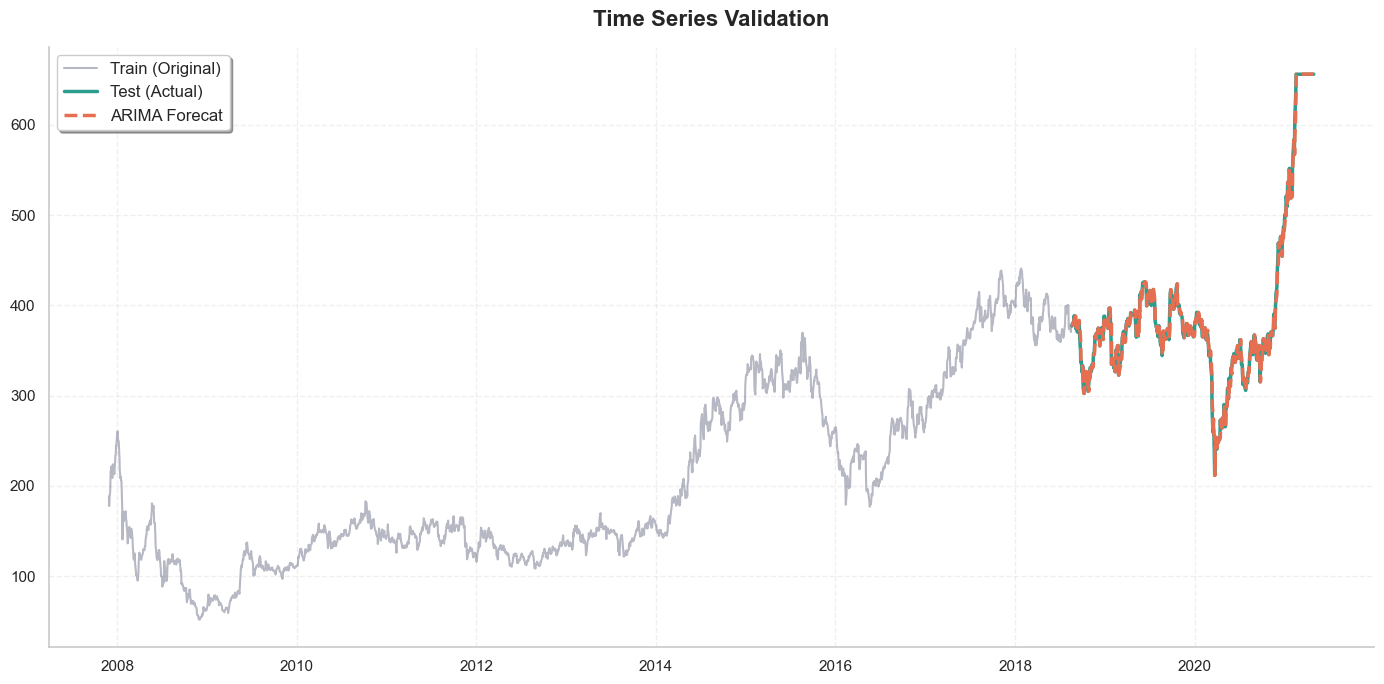

In [49]:
# Generating forecasts from the fitted ARIMA model on the test period.
preds = first_model.forecast(model_type='ARIMA')

# Converting the predicted values back to the original scale.
preds_orginal = first_model.inverse_transform(preds)

# Restoring the training and testing data to the original scale
# for a fair visual comparison with the forecasts.
train_orginal = first_model.inverse_transform(first_model.train_data)
test_orginal = first_model.inverse_transform(first_model.test_data)

# Ploting the original train data, actual test data, and ARIMA forecasts.
first_model.plot_validation(train=train_orginal,
                            test=test_orginal,
                            forcast=preds_orginal,
                            forecast_lable='ARIMA Forecat')

In [93]:
# Evaluating the ARIMA forecast using error metrics such as MAE and RMSE.

first_model.evaluate(pred=preds , model_type='ARIMA')

,0
Model Type,ARIMA
MAE,0.031616
RMSE,0.048265


## Scenario 2 – Modeling with Simple RNN algorithm

In [70]:
# Creating the modeling object using the prepared data.
# and keeping the preprocessing reference for restoring forecasts later.

second_model=Modeling(data=clean_data , prep=prepration)

In [71]:
# Split the data into training and testing sets and creating
# sequential windows for RNN modeling using a step size of 10.

second_model.train_test_split(model_type='RNN',step=10)

,0
Model Type,RNN
Step,10
X_train shape,"(2646, 10, 1)"
y_train shape,"(2646, 1)"
X_test shape,"(655, 10, 1)"
y_test shape,"(655, 1)"


In [72]:
# Build and train the RNN model using the prepared sequential training windows.

second_model.build_fit_rnn_model()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)               │ (None, 64)                  │           4,224 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,289 (16.75 KB)

 Trainable params: 4,289 (16.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
149/149 - 2s - 12ms/step - loss: 0.0030 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 2/100
149/149 - 0s - 3ms/step - loss: 0.0028 - val_loss: 0.0013 - learning_rate: 0.0010
Epoch 3/100
149/149 - 0s - 3ms/step - loss: 0.0028 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 4/100
149/149 - 0s - 3ms/step - loss: 0.0027 - val_loss: 0.0012 - learning_rate: 2.0000e-04
Epoch 5/100
149/149 - 0s - 3ms/step - loss: 0.0027 - val_loss: 0.0012 - learning_rate: 2.0000e-04
Epoch 6/100
149/149 - 0s - 3ms/step - loss: 0.0027 - val_loss: 0.0012 - learning_rate: 2.0000e-04
Epoch 7/100
149/149 - 0s - 3ms/step - loss: 0.0027 - val_loss: 0.0012 - learning_rate: 4.0000e-05
Epoch 8/100
149/149 - 0s - 3ms/step - loss: 0.0027 - val_loss: 0.0012 - learning_rate: 4.0000e-05
Epoch 9/100
149/149 - 0s - 3ms/step - loss: 0.0027 - val_loss: 0.0012 - learning_rate: 1.0000e-05
Epoch 10/100
149/149 - 0s - 3ms/step - loss: 0.0027 - val_loss: 0.0012 - learning_rate: 1.0000e-05
Epoch 11/100
149/149 - 0s - 3m

In [73]:
# Loading the TensorBoard extension and launch it
# to monitor RNN training logs saved in the `logs` directory.

%load_ext tensorboard
%tensorboard --logdir logs --port 6010

Reusing TensorBoard on port 6010 (pid 8360), started 2 days, 21:15:52 ago. (Use '!kill 8360' to kill it.)

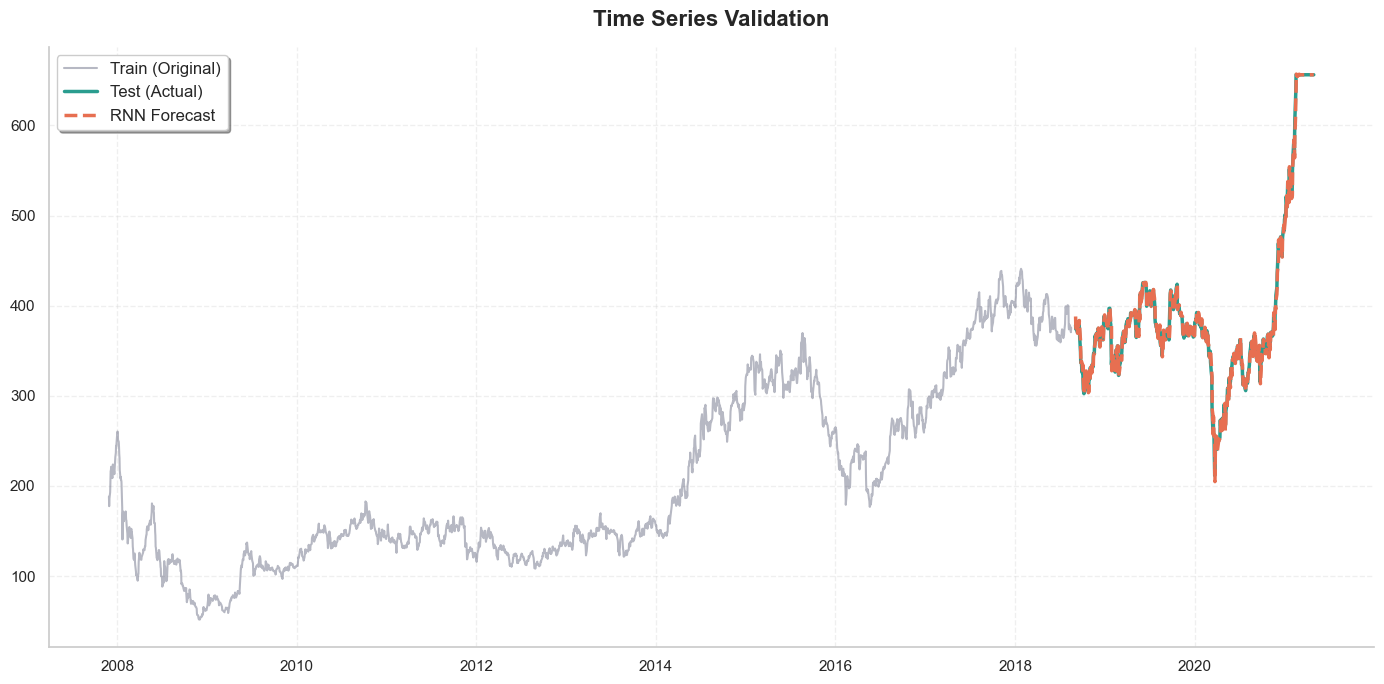

In [74]:
# Generating forecasts from the trained RNN model.
rnn_preds = second_model.forecast(model_type='RNN')

# Convert the predicted values back to the original scale.
preds_orginal = second_model.inverse_transform(rnn_preds)

# Restoring the training data and the aligned test segment
# to the original scale for comparison with the forecasts.
train_orginal = second_model.inverse_transform(second_model.train_data)
test_orginal = second_model.inverse_transform(second_model.test_data[second_model.rnn_step:])

# Ploting the original train data, actual test data, and RNN forecasts.
second_model.plot_validation(train=train_orginal,
                            test=test_orginal,
                            forcast=preds_orginal,
                            forecast_lable='RNN Forecast')

In [75]:
# Evaluate the RNN forecast using error metrics such as MAE and RMSE.

second_model.evaluate(pred=rnn_preds, model_type='RNN')

,0
Model Type,RNN
MAE,0.032154
RMSE,0.049313
